<a href="https://colab.research.google.com/github/abrown12005/CMP_SC-4540-HW/blob/main/HW11/PCAandKmeansExamples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This colab shows how to perform PCA using numpy and PyTorch on 2D and a 3D example

Used Claude as the vibe coding AI

We start with using numpy


Example 1: Two Points
Original Data:
[[1 3]
 [3 1]]

Mean: [2. 2.]
Covariance Matrix:
[[ 2. -2.]
 [-2.  2.]]

Eigenvalues: [4.0000000e+00 4.4408921e-16]
Principal Components:
PC1: [ 0.70710678 -0.70710678]
PC2: [0.70710678 0.70710678]


Example 2: Five Points
Original Data:
[[-2 -1]
 [-1  1]
 [ 0  0]
 [ 1  1]
 [ 2  1]]

Mean: [0.  0.4]
Covariance Matrix:
[[2.5 1. ]
 [1.  0.8]]

Eigenvalues: [2.96244047 0.33755953]
Principal Components:
PC1: [0.90764762 0.419733  ]
PC2: [-0.419733    0.90764762]



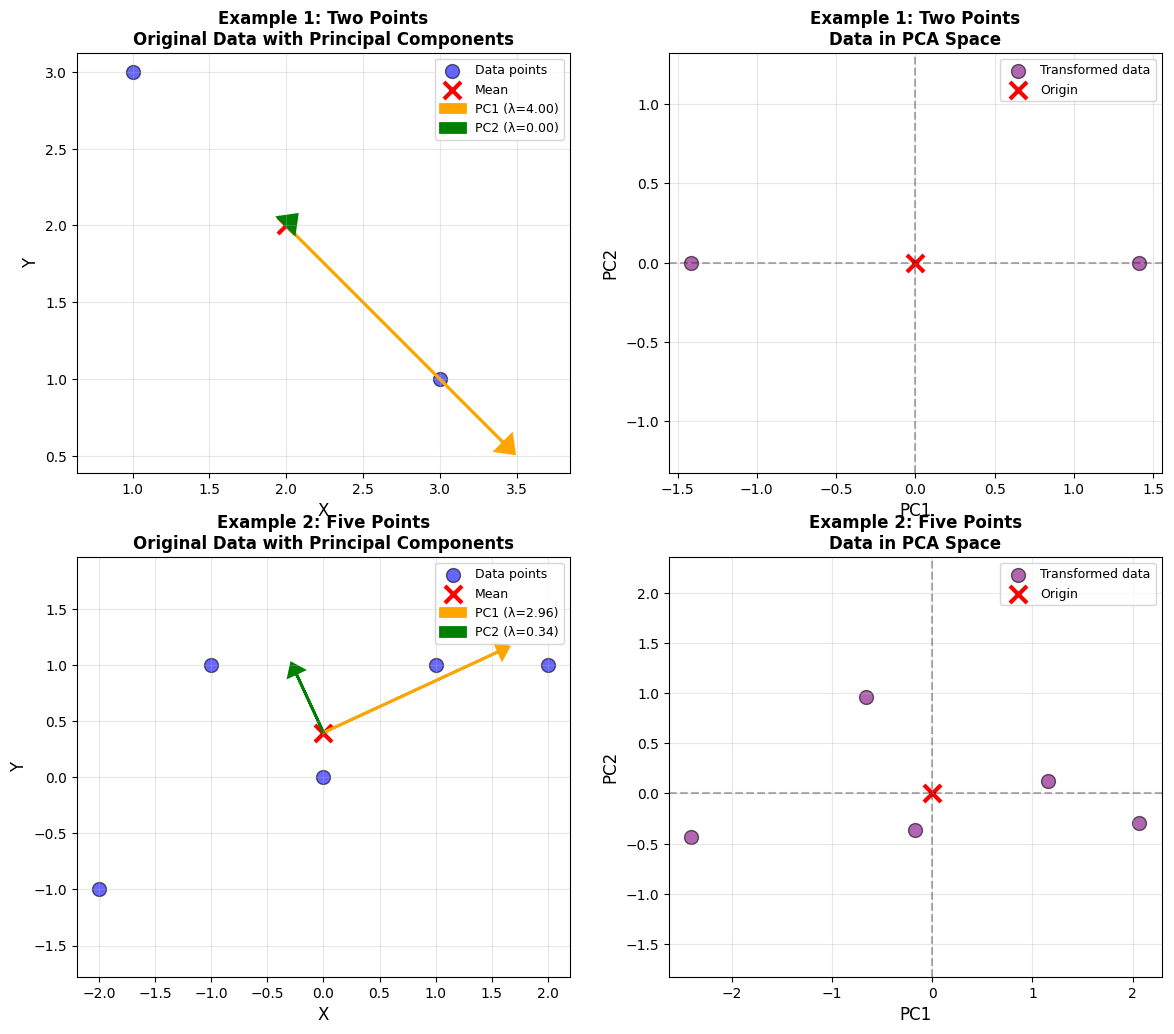

In [1]:
#Using numpy
import numpy as np
import matplotlib.pyplot as plt

def perform_pca(data, title=""):
    """Perform PCA on 2D data and return results."""
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print("Original Data:")
    print(data)
    print()

    # Step 1: Center the data (subtract mean)
    mean = np.mean(data, axis=0)
    centered_data = data - mean

    print("Mean:", mean)

    # Step 2: Compute covariance matrix
    cov_matrix = np.cov(centered_data.T)
    print("Covariance Matrix:")
    print(cov_matrix)
    print()

    # Step 3: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Step 4: Sort eigenvectors by eigenvalues (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    print("Eigenvalues:", eigenvalues)
    print("Principal Components:")
    print("PC1:", eigenvectors[:, 0])
    print("PC2:", eigenvectors[:, 1])
    print()

    # Step 5: Transform data to PCA space
    pca_data = centered_data @ eigenvectors

    return mean, eigenvalues, eigenvectors, pca_data


def plot_pca(data, mean, eigenvalues, eigenvectors, pca_data, title, ax1, ax2):
    """Create PCA visualization plots."""

    # Plot 1: Original data with principal components
    ax1.scatter(data[:, 0], data[:, 1], c='blue', s=100, alpha=0.6, edgecolors='black', label='Data points')
    ax1.scatter(mean[0], mean[1], c='red', s=150, marker='x', linewidths=3, label='Mean')

    # Draw principal component vectors from the mean
    scale = max(2, np.max(np.abs(data)) * 0.4)  # Adaptive scale
    for i in range(2):
        ax1.arrow(mean[0], mean[1],
                 eigenvectors[0, i] * scale * np.sqrt(eigenvalues[i]) * 0.5,
                 eigenvectors[1, i] * scale * np.sqrt(eigenvalues[i]) * 0.5,
                 head_width=0.15, head_length=0.1,
                 fc=['orange', 'green'][i], ec=['orange', 'green'][i],
                 linewidth=2, label=f'PC{i+1} (λ={eigenvalues[i]:.2f})')

    ax1.set_xlabel('X', fontsize=12)
    ax1.set_ylabel('Y', fontsize=12)
    ax1.set_title(f'{title}\nOriginal Data with Principal Components', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    ax1.axis('equal')

    # Plot 2: Data in PCA space
    ax2.scatter(pca_data[:, 0], pca_data[:, 1], c='purple', s=100, alpha=0.6, edgecolors='black', label='Transformed data')
    ax2.scatter(0, 0, c='red', s=150, marker='x', linewidths=3, label='Origin')
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax2.set_xlabel('PC1', fontsize=12)
    ax2.set_ylabel('PC2', fontsize=12)
    ax2.set_title(f'{title}\nData in PCA Space', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.axis('equal')


# Define multiple examples
examples = [
    {
        'data': np.array([[1, 3], [3, 1]]),
        'title': 'Example 1: Two Points'
    },
    {
        'data': np.array([[-2, -1], [-1, 1], [0, 0], [1, 1], [2, 1]]),
        'title': 'Example 2: Five Points'
    }
]

# Create figure with subplots for all examples
fig, axes = plt.subplots(len(examples), 2, figsize=(14, 6 * len(examples)))

# Handle case where there's only one example (axes won't be 2D)
if len(examples) == 1:
    axes = axes.reshape(1, -1)

# Process each example
for idx, example in enumerate(examples):
    data = example['data']
    title = example['title']

    # Perform PCA
    mean, eigenvalues, eigenvectors, pca_data = perform_pca(data, title)

    # Plot results
    plot_pca(data, mean, eigenvalues, eigenvectors, pca_data, title, axes[idx, 0], axes[idx, 1])

plt.show()

Now use PyTorch, as well as include the 3D example


Example 1: Two Points
Original Data:
tensor([[1., 3.],
        [3., 1.]])

Mean: tensor([2., 2.])
Covariance Matrix:
tensor([[ 2., -2.],
        [-2.,  2.]])

Eigenvalues: tensor([ 4.0000e+00, -2.3842e-07])
Principal Components:
PC1: tensor([ 0.7071, -0.7071])
PC2: tensor([0.7071, 0.7071])


Example 2: Five Points
Original Data:
tensor([[-2., -1.],
        [-1.,  1.],
        [ 0.,  0.],
        [ 1.,  1.],
        [ 2.,  1.]])

Mean: tensor([0.0000, 0.4000])
Covariance Matrix:
tensor([[2.5000, 1.0000],
        [1.0000, 0.8000]])

Eigenvalues: tensor([2.9624, 0.3376])
Principal Components:
PC1: tensor([0.9076, 0.4197])
PC2: tensor([-0.4197,  0.9076])


Example 3: 3D Points
Original Data:
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 9., 5.],
        [3., 7., 3.]])

Mean: tensor([3.7500, 5.7500, 4.2500])
Covariance Matrix:
tensor([[6.2500, 6.5833, 2.4167],
        [6.5833, 8.9167, 1.4167],
        [2.4167, 1.4167, 2.2500]])

Eigenvalues: tensor([14.8508,  2.3245,  0.2414])
P

/tmp/ipykernel_5959/1300821744.py:71: RuntimeWarning: invalid value encountered in scalar power
  eigenvectors_np[0, i] * scale * (eigenvalues_np[i] ** 0.5) * 0.5,
/tmp/ipykernel_5959/1300821744.py:72: RuntimeWarning: invalid value encountered in scalar power
  eigenvectors_np[1, i] * scale * (eigenvalues_np[i] ** 0.5) * 0.5,


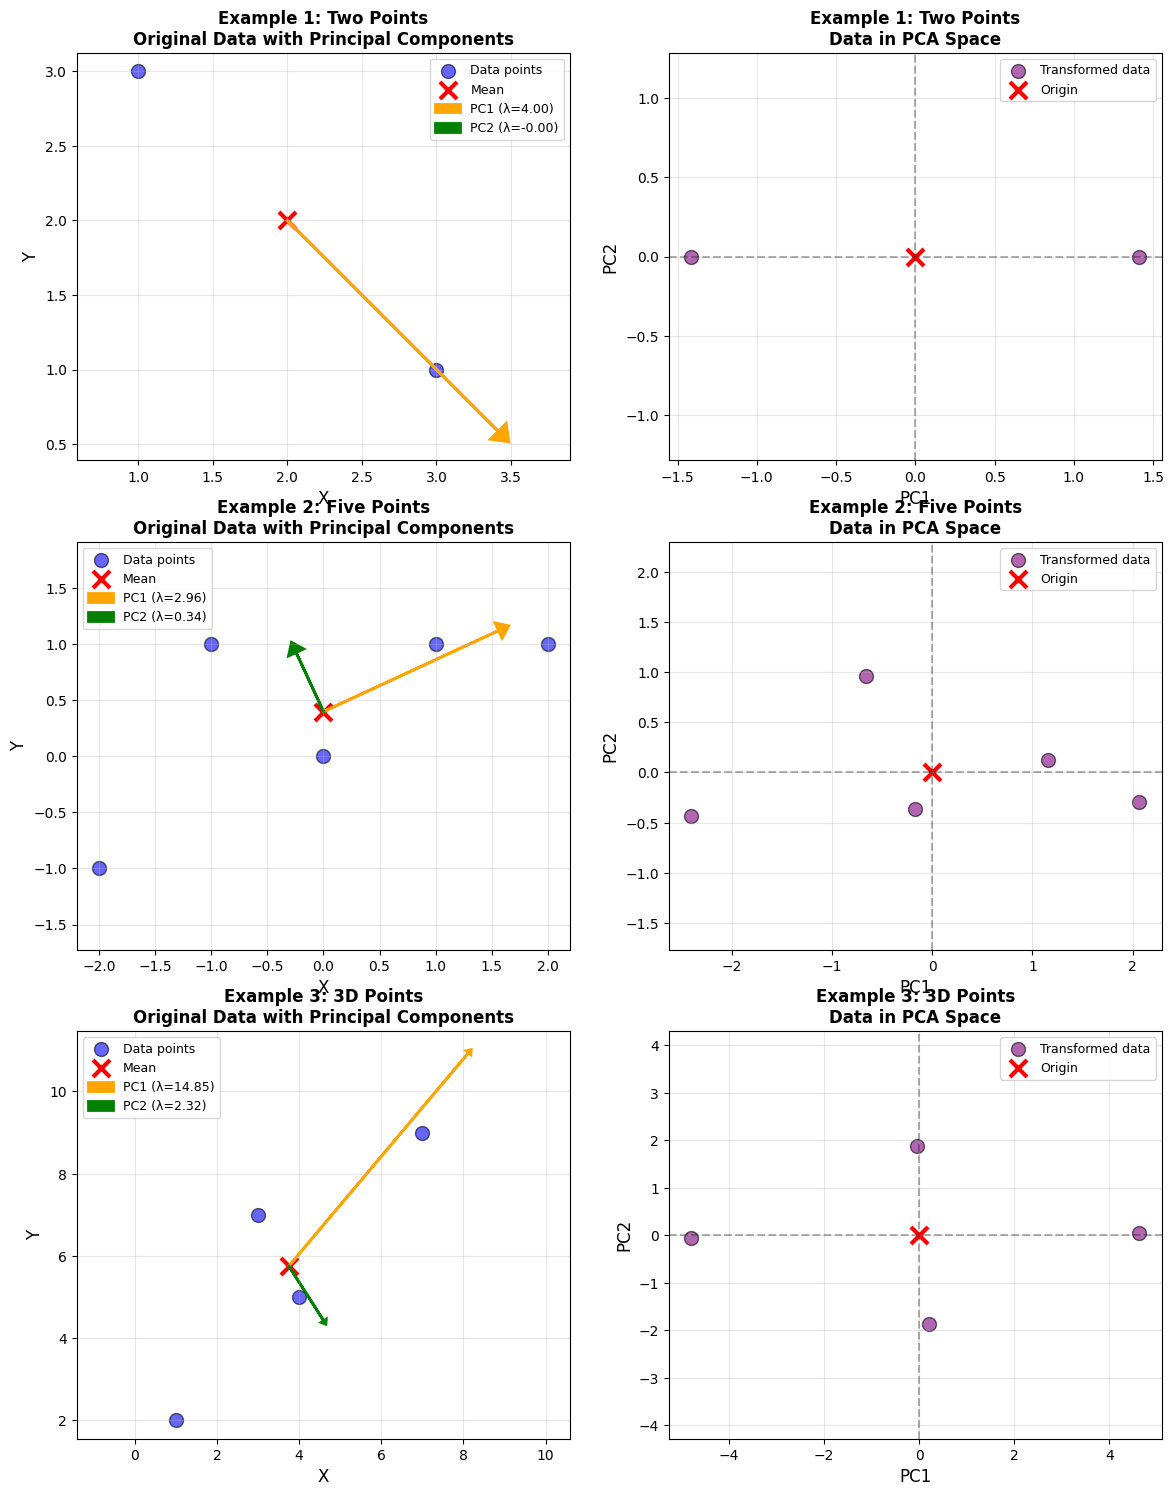

In [5]:
# Now use PyTorch
import torch
import matplotlib.pyplot as plt

def perform_pca(data, title=""):
    """Perform PCA on 2D data using PyTorch and return results."""
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print("Original Data:")
    print(data)
    print()

    # Step 1: Center the data (subtract mean)
    mean = torch.mean(data, dim=0)
    centered_data = data - mean

    print("Mean:", mean)

    # Step 2: Compute covariance matrix
    cov_matrix = torch.cov(centered_data.T)
    print("Covariance Matrix:")
    print(cov_matrix)
    print()

    # Step 3: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = torch.linalg.eig(cov_matrix)

    # Convert to real (eigenvalues/vectors should be real for covariance matrix)
    eigenvalues = eigenvalues.real
    eigenvectors = eigenvectors.real

    # Step 4: Sort eigenvectors by eigenvalues (descending)
    idx = torch.argsort(eigenvalues, descending=True)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    print("Eigenvalues:", eigenvalues)
    print("Principal Components:")
    print("PC1:", eigenvectors[:, 0])
    print("PC2:", eigenvectors[:, 1])
    if data.shape[1] == 3:
        print("PC3:", eigenvectors[:, 2])

    print()

    # Step 5: Transform data to PCA space
    pca_data = centered_data @ eigenvectors

    return mean, eigenvalues, eigenvectors, pca_data


def plot_pca(data, mean, eigenvalues, eigenvectors, pca_data, title, ax1, ax2):
    """Create PCA visualization plots."""

    # Convert tensors to numpy for plotting
    data_np = data.numpy()
    mean_np = mean.numpy()
    eigenvalues_np = eigenvalues.numpy()
    eigenvectors_np = eigenvectors.numpy()
    pca_data_np = pca_data.numpy()

    # Plot 1: Original data with principal components
    ax1.scatter(data_np[:, 0], data_np[:, 1], c='blue', s=100, alpha=0.6, edgecolors='black', label='Data points')
    ax1.scatter(mean_np[0], mean_np[1], c='red', s=150, marker='x', linewidths=3, label='Mean')

    # Draw principal component vectors from the mean
    scale = max(2, np.abs(data_np).max() * 0.4)  # Adaptive scale
    for i in range(2):
        ax1.arrow(mean_np[0], mean_np[1],
                 eigenvectors_np[0, i] * scale * (eigenvalues_np[i] ** 0.5) * 0.5,
                 eigenvectors_np[1, i] * scale * (eigenvalues_np[i] ** 0.5) * 0.5,
                 head_width=0.15, head_length=0.1,
                 fc=['orange', 'green'][i], ec=['orange', 'green'][i],
                 linewidth=2, label=f'PC{i+1} (λ={eigenvalues_np[i]:.2f})')

    ax1.set_xlabel('X', fontsize=12)
    ax1.set_ylabel('Y', fontsize=12)
    ax1.set_title(f'{title}\nOriginal Data with Principal Components', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    ax1.axis('equal')

    # Plot 2: Data in PCA space
    ax2.scatter(pca_data_np[:, 0], pca_data_np[:, 1], c='purple', s=100, alpha=0.6, edgecolors='black', label='Transformed data')
    ax2.scatter(0, 0, c='red', s=150, marker='x', linewidths=3, label='Origin')
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax2.set_xlabel('PC1', fontsize=12)
    ax2.set_ylabel('PC2', fontsize=12)
    ax2.set_title(f'{title}\nData in PCA Space', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.axis('equal')


# Define multiple examples using PyTorch tensors
examples = [
    {
        'data': torch.tensor([[1, 3], [3, 1]], dtype=torch.float32),
        'title': 'Example 1: Two Points'
    },
    {
        'data': torch.tensor([[-2, -1], [-1, 1], [0, 0], [1, 1], [2, 1]], dtype=torch.float32),
        'title': 'Example 2: Five Points'
    },
    {
        'data': torch.tensor([[1, 2, 3], [4, 5, 6], [7,9,5], [3,7,3]], dtype=torch.float32),
        'title':'Example 3: 3D Points'
    }
]

# Create figure with subplots for all examples
fig, axes = plt.subplots(len(examples), 2, figsize=(14, 6 * len(examples)))

# Handle case where there's only one example (axes won't be 2D)
if len(examples) == 1:
    axes = axes.reshape(1, -1)

# Process each example
for idx, example in enumerate(examples):
    data = example['data']
    title = example['title']

    # Perform PCA
    mean, eigenvalues, eigenvectors, pca_data = perform_pca(data, title)

    # Plot results
    plot_pca(data, mean, eigenvalues, eigenvectors, pca_data, title, axes[idx, 0], axes[idx, 1])

plt.show()

